In [1]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
from PIL import Image

model = YOLO("yolo26n-pose.pt")

WARNING ⚠️ Download failure, retrying 1/3 https://github.com/ultralytics/assets/releases/download/v8.4.0/yolo26n-pose.pt... <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)>


######################################################################## 100.0%


In [2]:
img_path = "/Users/yiyixu/Documents/School/Third Year/Winter/APS360/set.jpg"
results = model(img_path)


image 1/1 /Users/yiyixu/Documents/School/Third Year/Winter/APS360/set.jpg: 640x384 4 persons, 53.6ms
Speed: 1.7ms preprocess, 53.6ms inference, 0.2ms postprocess per image at shape (1, 3, 640, 384)


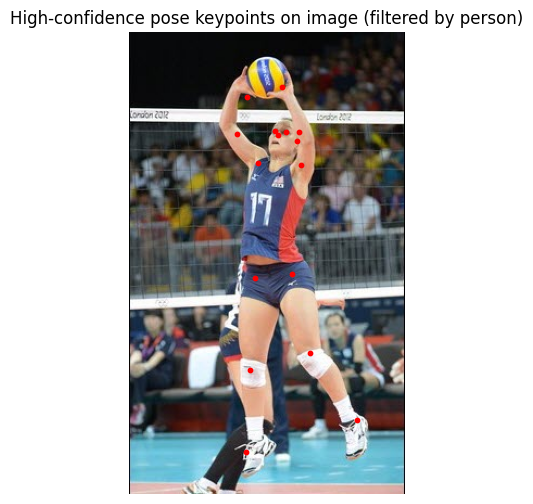

In [3]:

# Open the image
img = Image.open(img_path)

plt.figure(figsize=(8, 6))
plt.imshow(img)

# Only display high-confidence keypoints
confidence_threshold = 0.9  # adjust this between 0 and 1 as you like

# Only keep persons with enough high-confidence keypoints
min_points_per_person = 5  # threshold on number of points (change this as you like)

# Define a color list to cycle through for each person
def get_color(idx):
    colors = ['red', 'blue', 'green', 'yellow', 'cyan', 'magenta', 'orange', 'white']
    return colors[idx % len(colors)]

for result in results:
    kpts_xy = result.keypoints.xy        # (num_people, num_keypoints, 2)
    kpts_data = result.keypoints.data    # (num_people, num_keypoints, 3) -> (x, y, v)

    for person_idx, (person_xy, person_data) in enumerate(zip(kpts_xy, kpts_data)):
        vis = person_data[:, 2]  # visibility / confidence for each keypoint
        mask = vis > confidence_threshold

        # Count how many high-confidence points this person has
        num_high_conf_points = mask.sum().item()
        if num_high_conf_points < min_points_per_person:
            continue  # skip this person entirely

        xs = person_xy[mask, 0].cpu()
        ys = person_xy[mask, 1].cpu()
        plt.scatter(xs, ys, s=10, c=get_color(person_idx))

plt.axis('off')
plt.title('High-confidence pose keypoints on image (filtered by person)')
plt.show()

In [5]:
for i, r in enumerate(results):
    # Plot results image
    im_bgr = r.plot()  # BGR-order numpy array
    im_rgb = Image.fromarray(im_bgr[..., ::-1])  # RGB-order PIL image

    # Show results to screen (in supported environments)
    r.show(conf=False, boxes=False)